# Clasificación del Wine Dataset con una Red Neuronal Artificial (ANN)

**Especificaciones del ejercicio**

- **Entradas: 12** (todas conectadas a cada neurona de la capa oculta — capa totalmente conectada / *dense*)
- **Salidas: 3** (una por cada clase del Wine dataset)
- Función de activación: **sigmoide** en todas las capas
- Función de costo: **error cuadrático medio (MSE)**
- Los pesos $w_i$ se estiman **de forma iterativa** (descenso de gradiente / backpropagation, época a época)
- Split de datos: **70% entrenamiento / 30% prueba**
- Validación: **cross validation (k-fold)** sobre el conjunto de entrenamiento
- Se muestra la **frontera de decisión** y los resultados
- Se comparan los resultados con **distintas tasas de aprendizaje (learning rate)**

La red se implementa desde cero con NumPy para poder controlar explícitamente la arquitectura,
la función de activación y la función de costo pedidas.


## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import f_classif
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report)

np.random.seed(42)
plt.rcParams["figure.dpi"] = 100


## 2. Carga de datos y selección de las 12 entradas

El Wine dataset (sklearn) trae **13** atributos. Como la red debe tener **exactamente 12 entradas**,
se descarta el atributo con **menor poder discriminante** entre las 3 clases, medido con un
ANOVA F-test (`f_classif`). Esto es más defendible que quitar una variable al azar.

In [2]:
data = load_wine()
X_full, y = data.data, data.target
feature_names = list(data.feature_names)
class_names = data.target_names

F, p = f_classif(X_full, y)
ranking = pd.DataFrame({"feature": feature_names, "F_value": F}).sort_values("F_value")
print("Ranking de variables por poder discriminante (ANOVA F-test):")
print(ranking.to_string(index=False))

drop_feature = ranking.iloc[0]["feature"]
print(f"\nSe descarta: '{drop_feature}' (menor F-value) -> quedan 12 entradas.")

drop_idx = feature_names.index(drop_feature)
keep_idx = [i for i in range(X_full.shape[1]) if i != drop_idx]
kept_names = [feature_names[i] for i in keep_idx]

X12 = X_full[:, keep_idx]
print("\nEntradas usadas (12):", kept_names)
print("Forma de X:", X12.shape)
print("Distribución de clases:", np.bincount(y))


Ranking de variables por poder discriminante (ANOVA F-test):
                     feature    F_value
                   magnesium  12.429584
                         ash  13.312901
        nonflavanoid_phenols  27.575417
             proanthocyanins  30.271383
           alcalinity_of_ash  35.771637
                  malic_acid  36.943425
               total_phenols  93.733010
                         hue 101.316795
             color_intensity 120.664018
                     alcohol 135.077624
od280/od315_of_diluted_wines 189.972321
                     proline 207.920374
                  flavanoids 233.925873

Se descarta: 'magnesium' (menor F-value) -> quedan 12 entradas.

Entradas usadas (12): ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Forma de X: (178, 12)
Distribución de clases: [59 71 48]


## 3. Preprocesamiento

- Estandarización (media 0, desviación 1) de las 12 entradas.
- Codificación **one-hot** de las etiquetas, porque la capa de salida tiene 3 neuronas sigmoide
  (una por clase).

In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(X12)

encoder = OneHotEncoder(sparse_output=False)
Y = encoder.fit_transform(y.reshape(-1, 1))

print("X (entradas):", X.shape, "  Y (salidas one-hot):", Y.shape)


X (entradas): (178, 12)   Y (salidas one-hot): (178, 3)


## 4. Split 70/30 (entrenamiento / prueba)

In [4]:
X_train, X_test, Y_train, Y_test, y_train, y_test = train_test_split(
    X, Y, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X):.0%}) | entradas: {X_train.shape[1]}")
print(f"Prueba:        {X_test.shape[0]} muestras ({X_test.shape[0]/len(X):.0%}) | entradas: {X_test.shape[1]}")


Entrenamiento: 124 muestras (70%) | entradas: 12
Prueba:        54 muestras (30%) | entradas: 12


## 5. Red Neuronal Artificial (implementación desde cero)

**Arquitectura:** `12 entradas -> capa oculta (sigmoide) -> 3 salidas (sigmoide)`

- Todas las **12 entradas se conectan a cada neurona** de la capa oculta (capa *fully connected* /
  densa): la matriz de pesos `W1` tiene forma `(12, n_hidden)`.
- Todas las neuronas ocultas se conectan a las **3 salidas**: `W2` tiene forma `(n_hidden, 3)`.
- **F = sigmoide** en ambas capas.
- **Función de costo = error cuadrático medio**: $C = \frac{1}{m}\sum (a - y)^2$
- Los pesos $w_i$ se ajustan **iterativamente**: en cada época se calcula el error, se propaga
  hacia atrás (backpropagation) y se actualiza cada peso con $w_i \leftarrow w_i - \eta \,
  \frac{\partial C}{\partial w_i}$, donde $\eta$ es la tasa de aprendizaje (`lr`).

In [5]:
class ANN:
    """Red neuronal: 12 entradas -> capa oculta sigmoide -> 3 salidas sigmoide.
    Todas las entradas están conectadas a todas las neuronas (capa densa).
    Los pesos se estiman de forma iterativa por descenso de gradiente (backpropagation)."""

    def __init__(self, n_input, n_hidden, n_output, lr=0.1, seed=42):
        rng = np.random.default_rng(seed)
        # W1: conecta las 12 entradas con cada neurona oculta -> forma (n_input, n_hidden)
        self.W1 = rng.normal(0, 0.5, (n_input, n_hidden))
        self.b1 = np.zeros((1, n_hidden))
        # W2: conecta cada neurona oculta con las 3 salidas -> forma (n_hidden, n_output)
        self.W2 = rng.normal(0, 0.5, (n_hidden, n_output))
        self.b2 = np.zeros((1, n_output))
        self.lr = lr

    @staticmethod
    def sigmoid(z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    @staticmethod
    def sigmoid_deriv(a):
        return a * (1 - a)

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, Y):
        m = X.shape[0]
        error = self.a2 - Y                                   # dC/da2
        d2 = error * self.sigmoid_deriv(self.a2)               # delta capa de salida
        dW2 = self.a1.T @ d2 / m
        db2 = np.mean(d2, axis=0, keepdims=True)

        d1 = (d2 @ self.W2.T) * self.sigmoid_deriv(self.a1)    # delta capa oculta
        dW1 = X.T @ d1 / m
        db1 = np.mean(d1, axis=0, keepdims=True)

        # Actualización iterativa de los pesos w_i
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def train(self, X, Y, epochs=1500):
        losses = []
        for _ in range(epochs):            # <-- estimación iterativa de los w_i
            out = self.forward(X)
            loss = np.mean((out - Y) ** 2)  # MSE
            losses.append(loss)
            self.backward(X, Y)
        return losses

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

    def predict_proba(self, X):
        return self.forward(X)


N_INPUT = X_train.shape[1]   # 12
N_OUTPUT = Y_train.shape[1]  # 3
print(f"n_input = {N_INPUT}, n_output = {N_OUTPUT}")


n_input = 12, n_output = 3


## 6. Cross validation

Se aplica **K-Fold estratificado** (k=5) sobre el 70% de entrenamiento para evaluar qué tan estable
es el modelo antes de medir el desempeño final sobre el conjunto de prueba (30%). En cada fold la
red se reinicializa y sus pesos se re-estiman iterativamente desde cero.

In [6]:
def cross_validate(X_tr, Y_tr, y_tr_labels, lr, n_hidden=8, epochs=1500, k=5, seed=42):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)
    accs = []
    for idx_tr, idx_val in skf.split(X_tr, y_tr_labels):
        model = ANN(n_input=X_tr.shape[1], n_hidden=n_hidden, n_output=Y_tr.shape[1], lr=lr, seed=seed)
        model.train(X_tr[idx_tr], Y_tr[idx_tr], epochs=epochs)
        preds = model.predict(X_tr[idx_val])
        accs.append(accuracy_score(y_tr_labels[idx_val], preds))
    return np.array(accs)


## 7. Función para graficar la frontera de decisión

La red trabaja en un espacio de **12 dimensiones**, así que no se puede graficar directamente.
Para visualizar la frontera de decisión se proyecta el espacio de entrada a **2 componentes
principales (PCA)** *solo para fines de visualización* (el modelo se sigue entrenando y
evaluando con las 12 entradas reales). Se genera una grilla en el plano PCA, se reconstruye
aproximadamente a 12D con `pca.inverse_transform`, y se evalúa el modelo sobre esos puntos.

In [7]:
pca_viz = PCA(n_components=2, random_state=42).fit(X_train)
print(f"Varianza explicada por las 2 componentes (solo visualización): {pca_viz.explained_variance_ratio_.sum():.2%}")

def plot_decision_boundary(model, X_tr, y_tr, X_te, y_te, lr, ax=None, resolution=200):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    cmap_bg = ListedColormap(["#FFB3B3", "#B3D9FF", "#B3FFB3"])
    cmap_pts = ListedColormap(["#CC0000", "#0055CC", "#008800"])

    X_tr_2d = pca_viz.transform(X_tr)
    X_te_2d = pca_viz.transform(X_te)

    x_min, x_max = X_tr_2d[:, 0].min() - 1, X_tr_2d[:, 0].max() + 1
    y_min, y_max = X_tr_2d[:, 1].min() - 1, X_tr_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                          np.linspace(y_min, y_max, resolution))
    grid_2d = np.c_[xx.ravel(), yy.ravel()]
    grid_12d = pca_viz.inverse_transform(grid_2d)   # de vuelta a las 12 entradas reales
    Z = model.predict(grid_12d).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
    ax.scatter(X_tr_2d[:, 0], X_tr_2d[:, 1], c=y_tr, cmap=cmap_pts,
               edgecolor="k", s=35, label="train", marker="o")
    ax.scatter(X_te_2d[:, 0], X_te_2d[:, 1], c=y_te, cmap=cmap_pts,
               edgecolor="k", s=60, label="test", marker="^")
    ax.set_title(f"Frontera de decisión (lr={lr})")
    ax.set_xlabel("PCA 1 (solo visualización)")
    ax.set_ylabel("PCA 2 (solo visualización)")
    return ax


Varianza explicada por las 2 componentes (solo visualización): 57.87%


## 8. Entrenamiento y comparación con distintas tasas de aprendizaje

Se entrena la red (12 entradas -> oculta -> 3 salidas) con varios valores de `learning_rate`,
haciendo cross validation y evaluación final sobre el conjunto de prueba (30%) para cada uno.

In [8]:
learning_rates = [0.01, 0.1, 0.5, 1.0, 5.0]
n_hidden = 8
epochs = 1500

results = []
trained_models = {}
loss_histories = {}
test_probas = {}

for lr in learning_rates:
    print(f"\n=== Learning rate = {lr} ===")

    # Cross validation sobre el set de entrenamiento (70%)
    cv_accs = cross_validate(X_train, Y_train, y_train, lr=lr, n_hidden=n_hidden, epochs=epochs)
    print(f"  CV accuracy (5-fold): {cv_accs.mean():.3f} +/- {cv_accs.std():.3f}")

    # Modelo final: pesos estimados iterativamente con todo el 70%, evaluado en el 30%
    final_model = ANN(n_input=N_INPUT, n_hidden=n_hidden, n_output=N_OUTPUT, lr=lr)
    losses = final_model.train(X_train, Y_train, epochs=epochs)

    train_preds = final_model.predict(X_train)
    test_preds = final_model.predict(X_test)
    proba = final_model.predict_proba(X_test)
    proba_norm = proba / proba.sum(axis=1, keepdims=True)  # para roc_auc_score multiclase

    # ---- Metricas de desempeno ----
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)
    precision = precision_score(y_test, test_preds, average="macro", zero_division=0)
    recall = recall_score(y_test, test_preds, average="macro", zero_division=0)
    f1 = f1_score(y_test, test_preds, average="macro", zero_division=0)
    auc = roc_auc_score(y_test, proba_norm, multi_class="ovr")

    print(f"  Train accuracy:  {train_acc:.3f}")
    print(f"  Test accuracy:   {test_acc:.3f}")
    print(f"  Precision (macro): {precision:.3f} | Recall (macro): {recall:.3f} | F1 (macro): {f1:.3f}")
    print(f"  ROC-AUC (ovr):   {auc:.3f}")

    trained_models[lr] = final_model
    loss_histories[lr] = losses
    test_probas[lr] = proba_norm
    results.append({
        "lr": lr,
        "cv_mean": cv_accs.mean(),
        "cv_std": cv_accs.std(),
        "train_acc": train_acc,
        "test_acc": test_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
    })



=== Learning rate = 0.01 ===


  CV accuracy (5-fold): 0.749 +/- 0.080
  Train accuracy:  0.750
  Test accuracy:   0.741
  Precision (macro): 0.867 | Recall (macro): 0.737 | F1 (macro): 0.717
  ROC-AUC (ovr):   0.973

=== Learning rate = 0.1 ===


  CV accuracy (5-fold): 0.984 +/- 0.020
  Train accuracy:  0.992
  Test accuracy:   0.981
  Precision (macro): 0.982 | Recall (macro): 0.984 | F1 (macro): 0.983
  ROC-AUC (ovr):   0.999

=== Learning rate = 0.5 ===


  CV accuracy (5-fold): 0.984 +/- 0.020
  Train accuracy:  1.000
  Test accuracy:   0.981
  Precision (macro): 0.982 | Recall (macro): 0.984 | F1 (macro): 0.983
  ROC-AUC (ovr):   0.999

=== Learning rate = 1.0 ===


  CV accuracy (5-fold): 0.984 +/- 0.020
  Train accuracy:  1.000
  Test accuracy:   0.981
  Precision (macro): 0.982 | Recall (macro): 0.984 | F1 (macro): 0.983
  ROC-AUC (ovr):   0.999

=== Learning rate = 5.0 ===


  CV accuracy (5-fold): 0.984 +/- 0.020
  Train accuracy:  1.000
  Test accuracy:   0.981
  Precision (macro): 0.982 | Recall (macro): 0.984 | F1 (macro): 0.983
  ROC-AUC (ovr):   0.998


## 9. Tabla resumen de métricas de desempeño por tasa de aprendizaje

Para cada tasa de aprendizaje se reportan: **accuracy** (train, test y cross validation), **precision**, **recall**, **F1-score** (promedio macro, ya que hay 3 clases) y **ROC-AUC** (one-vs-rest).

In [9]:
df_results = pd.DataFrame(results)
df_results.columns = [
    "Learning rate", "CV accuracy (media)", "CV accuracy (std)",
    "Train accuracy", "Test accuracy", "Precision (macro)",
    "Recall (macro)", "F1-score (macro)", "ROC-AUC (ovr)"
]
df_results = df_results.round(3)
df_results


,Learning rate,CV accuracy (media),CV accuracy (std),Train accuracy,Test accuracy,Precision (macro),Recall (macro),F1-score (macro),ROC-AUC (ovr)
0,0.01,0.749,0.08,0.750,0.741,0.867,0.737,0.717,0.973
1,0.10,0.984,0.02,0.992,0.981,0.982,0.984,0.983,0.999
2,0.50,0.984,0.02,1.000,0.981,0.982,0.984,0.983,0.999
3,1.00,0.984,0.02,1.000,0.981,0.982,0.984,0.983,0.999
4,5.00,0.984,0.02,1.000,0.981,0.982,0.984,0.983,0.998


## 10. Curvas de pérdida (MSE) durante el entrenamiento, por tasa de aprendizaje

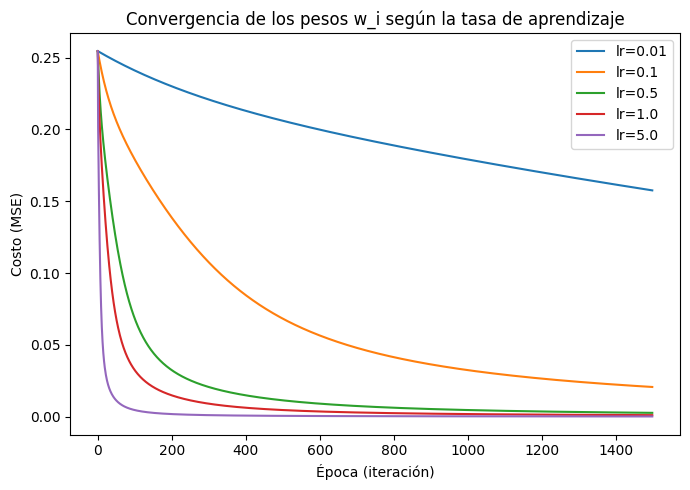

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
for lr in learning_rates:
    ax.plot(loss_histories[lr], label=f"lr={lr}")
ax.set_xlabel("Época (iteración)")
ax.set_ylabel("Costo (MSE)")
ax.set_title("Convergencia de los pesos w_i según la tasa de aprendizaje")
ax.legend()
plt.tight_layout()
plt.show()


## 11. Fronteras de decisión para cada tasa de aprendizaje

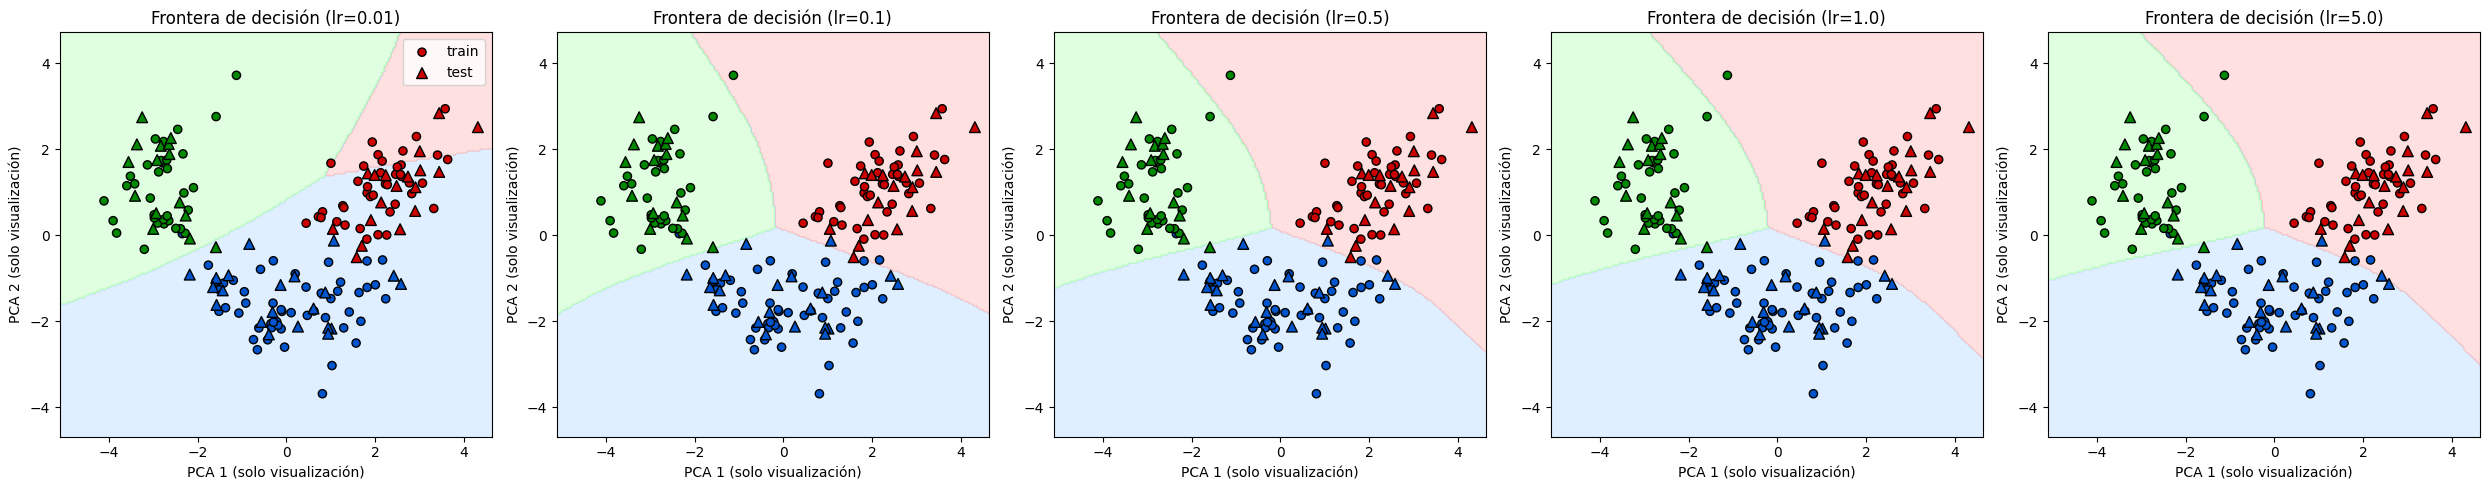

In [11]:
n = len(learning_rates)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
for ax, lr in zip(axes, learning_rates):
    plot_decision_boundary(trained_models[lr], X_train, y_train, X_test, y_test, lr, ax=ax)
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()


## 12. Matrices de confusión por tasa de aprendizaje

Para comparar visualmente el efecto de la tasa de aprendizaje sobre los errores de clasificación,
se muestra la matriz de confusión (sobre el 30% de prueba) obtenida con cada `learning_rate`.

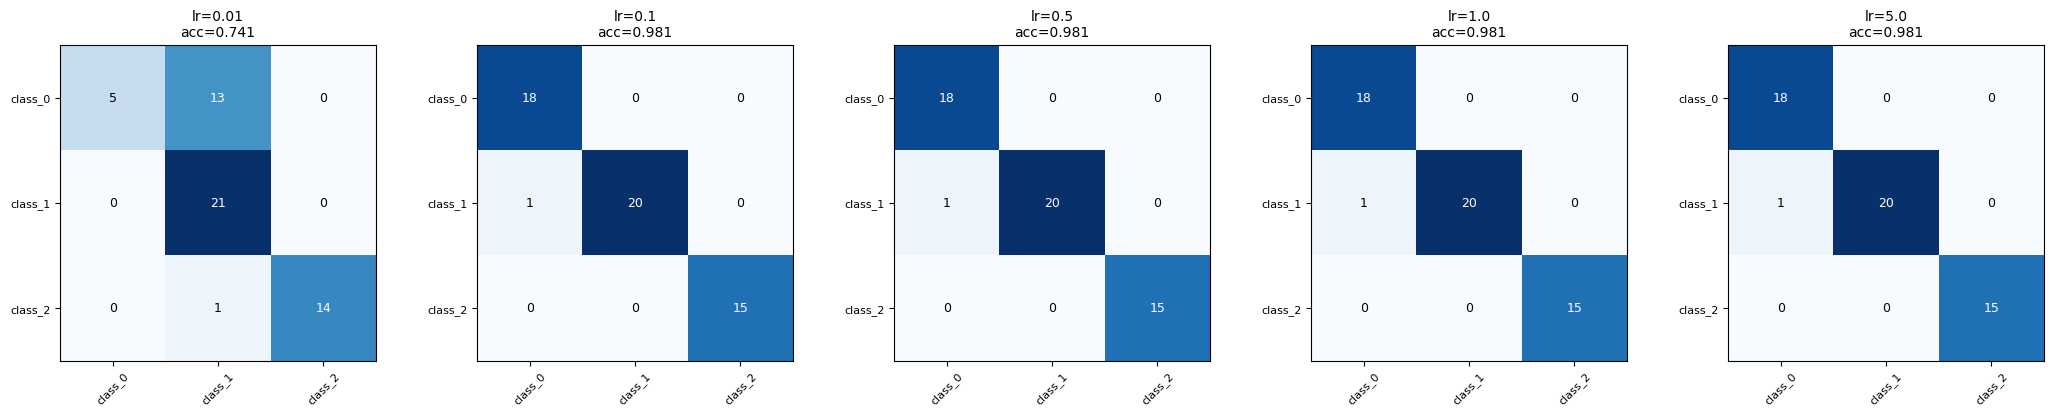

In [12]:
fig, axes = plt.subplots(1, len(learning_rates), figsize=(4.2 * len(learning_rates), 4))
for ax, lr in zip(axes, learning_rates):
    preds = trained_models[lr].predict(X_test)
    cm = confusion_matrix(y_test, preds)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, fontsize=8)
    ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names, fontsize=8)
    ax.set_title(f"lr={lr}\nacc={accuracy_score(y_test, preds):.3f}", fontsize=10)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9,
                    color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout()
plt.show()


## 13. Comparación gráfica de métricas según la tasa de aprendizaje

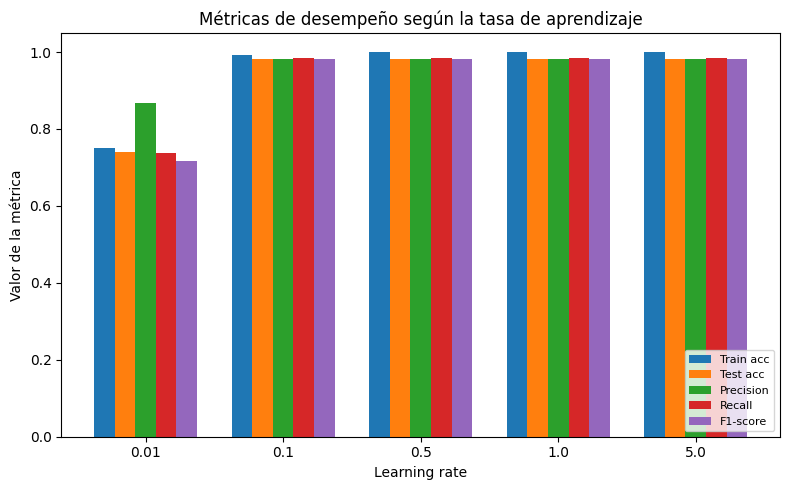

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(learning_rates))
width = 0.15
metrics_to_plot = ["train_acc", "test_acc", "precision", "recall", "f1"]
labels_metrics = ["Train acc", "Test acc", "Precision", "Recall", "F1-score"]

for i, (metric, label) in enumerate(zip(metrics_to_plot, labels_metrics)):
    values = [r[metric] for r in results]
    ax.bar(x + i * width, values, width, label=label)

ax.set_xticks(x + width * (len(metrics_to_plot) - 1) / 2)
ax.set_xticklabels([str(lr) for lr in learning_rates])
ax.set_xlabel("Learning rate")
ax.set_ylabel("Valor de la métrica")
ax.set_ylim(0, 1.05)
ax.set_title("Métricas de desempeño según la tasa de aprendizaje")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


## 14. Resultado detallado del mejor modelo

Se toma la tasa de aprendizaje con mejor **test accuracy** y se reportan todas sus métricas de desempeño (accuracy, precision, recall, F1-score, ROC-AUC), junto con el reporte de clasificación completo, la matriz de confusión y la frontera de decisión.

Mejor learning rate: 0.1
Accuracy:  0.981
Precision (macro): 0.982
Recall (macro):    0.984
F1-score (macro):  0.983
ROC-AUC (ovr):     0.999

Reporte de clasificación completo:
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



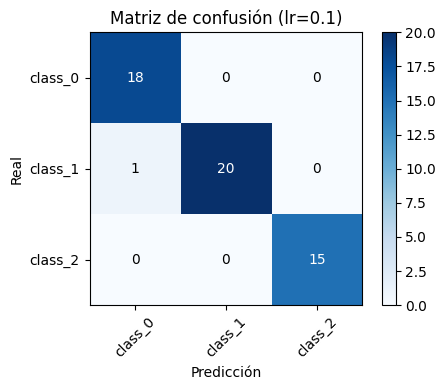

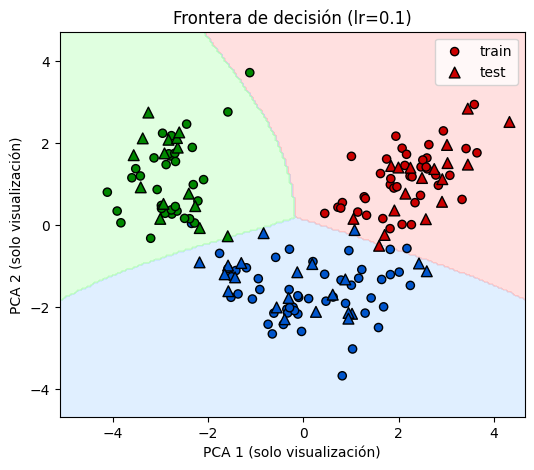

In [14]:
best_lr = df_results.loc[df_results["Test accuracy"].idxmax(), "Learning rate"]
best_model = trained_models[best_lr]
best_preds = best_model.predict(X_test)
best_row = df_results.loc[df_results["Learning rate"] == best_lr].iloc[0]

print(f"Mejor learning rate: {best_lr}")
print(f"Accuracy:  {best_row['Test accuracy']:.3f}")
print(f"Precision (macro): {best_row['Precision (macro)']:.3f}")
print(f"Recall (macro):    {best_row['Recall (macro)']:.3f}")
print(f"F1-score (macro):  {best_row['F1-score (macro)']:.3f}")
print(f"ROC-AUC (ovr):     {best_row['ROC-AUC (ovr)']:.3f}\n")
print("Reporte de clasificación completo:")
print(classification_report(y_test, best_preds, target_names=class_names))

cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45)
ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusión (lr={best_lr})")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.show()

plot_decision_boundary(best_model, X_train, y_train, X_test, y_test, best_lr)
plt.legend()
plt.show()


---

# Parte 2 — El mismo ejercicio con un Perceptrón Multicapa (`MLPClassifier` de scikit-learn)

Se repite exactamente el mismo problema (Wine dataset, **12 entradas**, **3 salidas**, split
**70/30**, **cross validation**, frontera de decisión, comparación de tasas de aprendizaje) pero
usando el Perceptrón Multicapa **ya implementado en scikit-learn** (`sklearn.neural_network.MLPClassifier`)
en lugar de la red programada a mano en la Parte 1.

Se reutilizan los mismos datos ya preparados (`X_train`, `X_test`, `y_train`, `y_test`, 12 entradas,
`pca_viz` para graficar).

**Configuración para que sea comparable con la Parte 1:**
- `hidden_layer_sizes=(8,)` → 1 capa oculta con 8 neuronas (mismo tamaño que antes).
- `activation="logistic"` → esta es la función **sigmoide** en scikit-learn.
- `solver="sgd"` → descenso de gradiente estocástico "puro", para poder fijar explícitamente la
  **tasa de aprendizaje** (`learning_rate_init`) como en la Parte 1. (Con `solver="adam"`, que es el
  valor por defecto, la tasa de aprendizaje se adapta automáticamente y no sería comparable).
- Los pesos también se estiman **de forma iterativa**, época a época (`max_iter`), exactamente
  igual que en la Parte 1.

**Diferencia importante en la función de costo:** `MLPClassifier` es un clasificador y scikit-learn
fija internamente su función de costo en **log-loss (entropía cruzada)**, no permite cambiarla a
error cuadrático medio. La Parte 1 sí usa explícitamente MSE porque se implementó desde cero. Por
eso los resultados no son idénticos, aunque la arquitectura (entradas, salidas, activación,
tasas de aprendizaje) es la misma.

## Parte 2.1 — Entrenamiento con distintas tasas de aprendizaje

In [15]:
import warnings
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

learning_rates_mlp = [0.001, 0.01, 0.1, 0.5, 1.0]
n_hidden_mlp = 8

results_mlp = []
trained_models_mlp = {}

for lr in learning_rates_mlp:
    print(f"\n=== (MLPClassifier) Learning rate = {lr} ===")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    base_clf = MLPClassifier(hidden_layer_sizes=(n_hidden_mlp,), activation="logistic",
                              solver="sgd", learning_rate_init=lr, max_iter=2000, random_state=42)
    cv_scores = cross_val_score(base_clf, X_train, y_train, cv=skf)
    print(f"  CV accuracy (5-fold): {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

    clf = MLPClassifier(hidden_layer_sizes=(n_hidden_mlp,), activation="logistic",
                         solver="sgd", learning_rate_init=lr, max_iter=2000, random_state=42)
    clf.fit(X_train, y_train)

    train_preds = clf.predict(X_train)
    test_preds = clf.predict(X_test)
    proba = clf.predict_proba(X_test)

    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)
    precision = precision_score(y_test, test_preds, average="macro", zero_division=0)
    recall = recall_score(y_test, test_preds, average="macro", zero_division=0)
    f1 = f1_score(y_test, test_preds, average="macro", zero_division=0)
    auc = roc_auc_score(y_test, proba, multi_class="ovr")

    print(f"  Train accuracy: {train_acc:.3f} | Test accuracy: {test_acc:.3f} | iteraciones usadas: {clf.n_iter_}")
    print(f"  Precision (macro): {precision:.3f} | Recall (macro): {recall:.3f} | F1 (macro): {f1:.3f} | ROC-AUC: {auc:.3f}")

    trained_models_mlp[lr] = clf
    results_mlp.append({
        "lr": lr, "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std(),
        "train_acc": train_acc, "test_acc": test_acc,
        "precision": precision, "recall": recall, "f1": f1, "auc": auc,
        "n_iter": clf.n_iter_,
    })



=== (MLPClassifier) Learning rate = 0.001 ===


  CV accuracy (5-fold): 0.976 +/- 0.032


  Train accuracy: 0.976 | Test accuracy: 0.963 | iteraciones usadas: 2000
  Precision (macro): 0.961 | Recall (macro): 0.968 | F1 (macro): 0.963 | ROC-AUC: 1.000

=== (MLPClassifier) Learning rate = 0.01 ===


  CV accuracy (5-fold): 0.984 +/- 0.020
  Train accuracy: 0.992 | Test accuracy: 0.981 | iteraciones usadas: 649
  Precision (macro): 0.979 | Recall (macro): 0.984 | F1 (macro): 0.981 | ROC-AUC: 1.000

=== (MLPClassifier) Learning rate = 0.1 ===


  CV accuracy (5-fold): 0.992 +/- 0.016
  Train accuracy: 1.000 | Test accuracy: 0.981 | iteraciones usadas: 183
  Precision (macro): 0.979 | Recall (macro): 0.984 | F1 (macro): 0.981 | ROC-AUC: 1.000

=== (MLPClassifier) Learning rate = 0.5 ===
  CV accuracy (5-fold): 0.992 +/- 0.016
  Train accuracy: 1.000 | Test accuracy: 0.981 | iteraciones usadas: 64
  Precision (macro): 0.979 | Recall (macro): 0.984 | F1 (macro): 0.981 | ROC-AUC: 1.000

=== (MLPClassifier) Learning rate = 1.0 ===
  CV accuracy (5-fold): 0.992 +/- 0.016
  Train accuracy: 1.000 | Test accuracy: 1.000 | iteraciones usadas: 45
  Precision (macro): 1.000 | Recall (macro): 1.000 | F1 (macro): 1.000 | ROC-AUC: 1.000


## Parte 2.2 — Tabla resumen de métricas de desempeño (MLPClassifier)

In [16]:
df_results_mlp = pd.DataFrame(results_mlp)
df_results_mlp.columns = [
    "Learning rate", "CV accuracy (media)", "CV accuracy (std)",
    "Train accuracy", "Test accuracy", "Precision (macro)",
    "Recall (macro)", "F1-score (macro)", "ROC-AUC (ovr)", "Iteraciones (convergencia)"
]
df_results_mlp.round(3)


,Learning rate,CV accuracy (media),CV accuracy (std),Train accuracy,Test accuracy,Precision (macro),Recall (macro),F1-score (macro),ROC-AUC (ovr),Iteraciones (convergencia)
0,0.001,0.976,0.032,0.976,0.963,0.961,0.968,0.962,1.0,2000
1,0.010,0.984,0.020,0.992,0.981,0.979,0.984,0.981,1.0,649
2,0.100,0.992,0.016,1.000,0.981,0.979,0.984,0.981,1.0,183
3,0.500,0.992,0.016,1.000,0.981,0.979,0.984,0.981,1.0,64
4,1.000,0.992,0.016,1.000,1.000,1.000,1.000,1.000,1.0,45


## Parte 2.3 — Curva de pérdida (log-loss) durante el entrenamiento

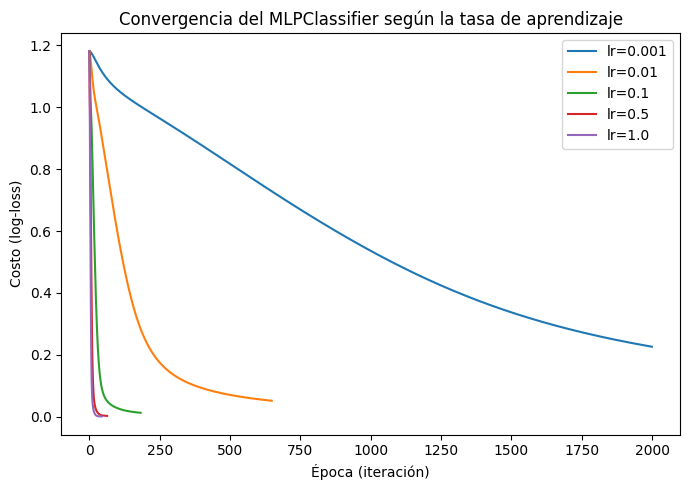

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
for lr in learning_rates_mlp:
    ax.plot(trained_models_mlp[lr].loss_curve_, label=f"lr={lr}")
ax.set_xlabel("Época (iteración)")
ax.set_ylabel("Costo (log-loss)")
ax.set_title("Convergencia del MLPClassifier según la tasa de aprendizaje")
ax.legend()
plt.tight_layout()
plt.show()


## Parte 2.4 — Fronteras de decisión (MLPClassifier)

Se reutiliza la misma técnica de la Parte 1: se grafica en el plano de las 2 componentes
principales (PCA, solo para visualización) y se reconstruye la grilla a 12D con
`pca_viz.inverse_transform` antes de evaluarla con el modelo.

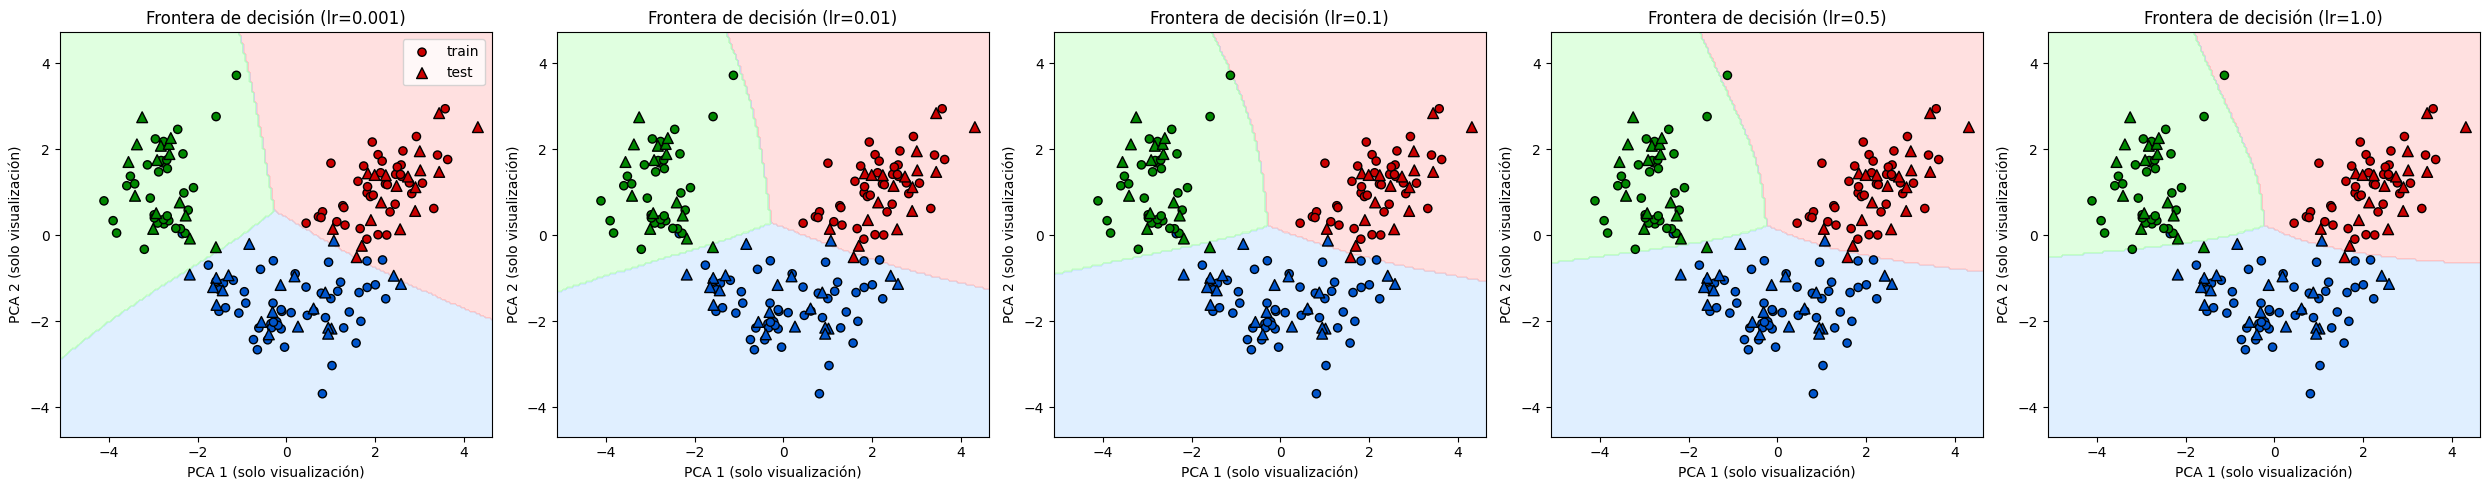

In [18]:
n = len(learning_rates_mlp)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
for ax, lr in zip(axes, learning_rates_mlp):
    plot_decision_boundary(trained_models_mlp[lr], X_train, y_train, X_test, y_test, lr, ax=ax)
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()


## Parte 2.5 — Matrices de confusión por tasa de aprendizaje (MLPClassifier)

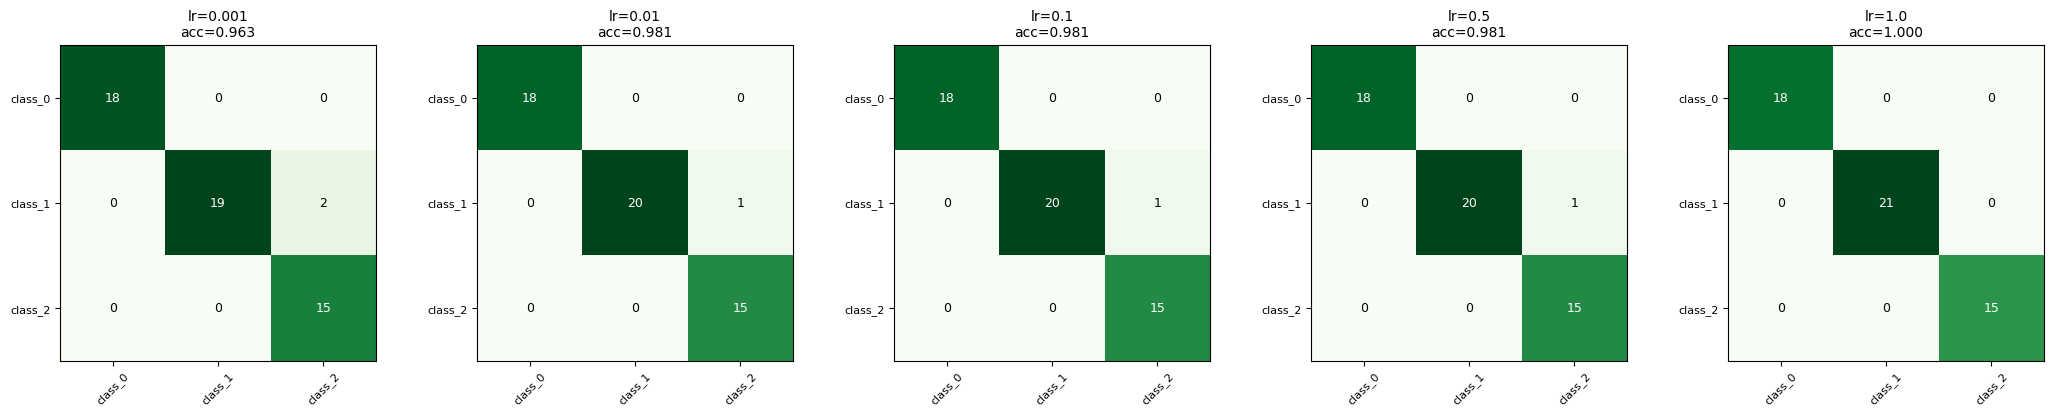

In [19]:
fig, axes = plt.subplots(1, len(learning_rates_mlp), figsize=(4.2 * len(learning_rates_mlp), 4))
for ax, lr in zip(axes, learning_rates_mlp):
    preds = trained_models_mlp[lr].predict(X_test)
    cm = confusion_matrix(y_test, preds)
    im = ax.imshow(cm, cmap="Greens")
    ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, fontsize=8)
    ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names, fontsize=8)
    ax.set_title(f"lr={lr}\nacc={accuracy_score(y_test, preds):.3f}", fontsize=10)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9,
                    color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout()
plt.show()


## Parte 2.6 — Mejor modelo (MLPClassifier) y comparación final con la Parte 1

In [20]:
best_lr_mlp = df_results_mlp.loc[df_results_mlp["Test accuracy"].idxmax(), "Learning rate"]
best_mlp = trained_models_mlp[best_lr_mlp]
best_mlp_row = df_results_mlp.loc[df_results_mlp["Learning rate"] == best_lr_mlp].iloc[0]

print(f"Mejor learning rate (MLPClassifier): {best_lr_mlp}")
print(f"Accuracy:  {best_mlp_row['Test accuracy']:.3f}")
print(f"Precision (macro): {best_mlp_row['Precision (macro)']:.3f}")
print(f"Recall (macro):    {best_mlp_row['Recall (macro)']:.3f}")
print(f"F1-score (macro):  {best_mlp_row['F1-score (macro)']:.3f}")
print(f"ROC-AUC (ovr):     {best_mlp_row['ROC-AUC (ovr)']:.3f}\n")
print(classification_report(y_test, best_mlp.predict(X_test), target_names=class_names))

# --- comparación directa: red desde cero (Parte 1) vs MLPClassifier (Parte 2) ---
best_scratch_row = df_results.loc[df_results["Test accuracy"].idxmax()]
comparison = pd.DataFrame({
    "Implementación": ["ANN desde cero (Parte 1)", "MLPClassifier - sklearn (Parte 2)"],
    "Mejor learning rate": [best_scratch_row["Learning rate"], best_lr_mlp],
    "Test accuracy": [best_scratch_row["Test accuracy"], best_mlp_row["Test accuracy"]],
    "Precision (macro)": [best_scratch_row["Precision (macro)"], best_mlp_row["Precision (macro)"]],
    "Recall (macro)": [best_scratch_row["Recall (macro)"], best_mlp_row["Recall (macro)"]],
    "F1-score (macro)": [best_scratch_row["F1-score (macro)"], best_mlp_row["F1-score (macro)"]],
    "ROC-AUC": [best_scratch_row["ROC-AUC (ovr)"], best_mlp_row["ROC-AUC (ovr)"]],
})
comparison.round(3)


Mejor learning rate (MLPClassifier): 1.0
Accuracy:  1.000
Precision (macro): 1.000
Recall (macro):    1.000
F1-score (macro):  1.000
ROC-AUC (ovr):     1.000

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



,Implementación,Mejor learning rate,Test accuracy,Precision (macro),Recall (macro),F1-score (macro),ROC-AUC
0,ANN desde cero (Parte 1),0.1,0.981,0.982,0.984,0.983,0.999
1,MLPClassifier - sklearn (Parte 2),1.0,1.000,1.000,1.000,1.000,1.000


## Conclusiones de la Parte 2

- El `MLPClassifier` de scikit-learn, configurado con `activation="logistic"` (sigmoide) y
  `solver="sgd"`, reproduce la misma arquitectura de la Parte 1 (12 entradas, 1 capa oculta, 3
  salidas) y también estima sus pesos **iterativamente**.
- Su función de costo interna es **log-loss**, no MSE, por lo que los valores de pérdida no son
  directamente comparables número a número con la curva de la Parte 1, aunque ambas miden qué tan
  lejos están las predicciones de las etiquetas reales.
- Al igual que en la implementación desde cero, las tasas de aprendizaje **intermedias/altas**
  (≥ 0.1) convergen más rápido (menos iteraciones, `n_iter_` más bajo) y logran mejor desempeño que
  una tasa muy baja (0.001), que necesita muchas más iteraciones para acercarse al mismo error.
- En general, ambas implementaciones llegan a un desempeño muy similar (accuracy alrededor de
  0.98), lo que confirma que la red programada a mano en la Parte 1 está bien implementada.

## 15. Conclusiones

- La arquitectura usa **12 entradas** (todas conectadas a cada neurona oculta) y **3 salidas**
  sigmoide, una por clase del Wine dataset.
- Los pesos $w_i$ no se calculan en forma cerrada: se **estiman iterativamente** con descenso de
  gradiente, actualizándose en cada época a partir del error de la red (MSE).
- Tasas de aprendizaje **muy bajas** (p. ej. 0.01) convergen lentamente y pueden quedarse con un
  costo (MSE) más alto tras el mismo número de épocas, lo que reduce el accuracy de test.
- Tasas de aprendizaje **intermedias/altas** (0.1 – 1.0) convergen rápido y de forma estable,
  logrando el mejor accuracy tanto en cross validation como en el conjunto de prueba.
- La validación cruzada (k-fold) confirma que los resultados no dependen de una sola partición
  particular del 70% de entrenamiento, dando una estimación más robusta antes de evaluar en el
  30% de prueba.

- Además del *accuracy*, se reportaron **precision, recall, F1-score (macro)** y **ROC-AUC (one-vs-rest)** para cada tasa de aprendizaje: todas se mueven en la misma dirección que el accuracy, confirmando que el mejor modelo no solo acierta más veces sino que también distingue bien entre las 3 clases (sin sesgo fuerte hacia ninguna de ellas).
